# SkyFinder DIR — Training

**Models:**
- **B1** — plain ResNet-50 regression (baseline)
- **D1** — + Label Distribution Smoothing (LDS)
- **D2** — + LDS + Feature Distribution Smoothing (FDS)

**Prerequisite:** `skyfinder_split.csv` exists in Drive (output of the earlier split cell).

**Goal**: Apply Yang et al. 2021 *Delving into Deep Imbalanced Regression*
(LDS + FDS + RRT) to the SkyFinder dataset for image-based temperature
regression, and report few/medium/many-shot performance vs. a vanilla regression baseline.

## Reproduction guide

For the corrected LDS experiment, run:
Setup/paths → Library code → Base B1 config → D1 → D1_inv → D2 → D2_inv → Re-evaluation.

## Metrics

For overall and each shot region (few / medium / many):
- **RMSE** — sensitive to outliers
- **MAE** — robust mean
- **GM** — geometric mean of |error|, paper-recommended balanced metric

## Key findings (preview)


## 1. Setup

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:  {torch.cuda.get_device_name(0)}")

from pathlib import Path
DRIVE_ROOT     = Path("/content/drive/MyDrive/Colab Notebooks/SkyFinder")
SPLIT_CSV      = DRIVE_ROOT / "data/skyfinder_split.csv"
DRIVE_IMG_ROOT = DRIVE_ROOT / "images"
LOCAL_IMG_ROOT = Path("/content/skyfinder_images")
RUNS_ROOT      = Path("/content/runs"); RUNS_ROOT.mkdir(exist_ok=True)

assert SPLIT_CSV.exists(), f"Split CSV not found: {SPLIT_CSV}"
print(f"\nSplit CSV: {SPLIT_CSV}")

Mounted at /content/drive
PyTorch: 2.10.0+cu128
CUDA: True
GPU:  NVIDIA A100-SXM4-80GB


## 2. Library

Defines everything: dataset, model, losses, training loop. Run this cell once;
all training cells below call `train_model(cfg)` from here.


### 2.1 Imports, Helper Functions, Dataset, Model, Training Loop

In [4]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [5]:
# --- imports ---
import json
import time
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm
from PIL import Image
from scipy.ndimage import convolve1d
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# =============================================================================
# Bin + shot helpers
# =============================================================================
TEMP_MIN, TEMP_MAX = -30.0, 55.0    # covers actual data range [-27.2, 50.0]
BIN_SIZE = 1.0                       # 1°C per bin (DIR convention)
N_BINS = int(round((TEMP_MAX - TEMP_MIN) / BIN_SIZE))

def temp_to_bin(t):
    t = max(TEMP_MIN, min(TEMP_MAX - 1e-6, float(t)))
    return int((t - TEMP_MIN) / BIN_SIZE)

def get_train_bin_counts(csv_path):
    """Count training samples per bin. Used by LDS weight computation."""
    df = pd.read_csv(csv_path)
    df = df[df["split"] == "train"]
    bins = np.clip(((df["temperature_c"].values - TEMP_MIN) / BIN_SIZE).astype(int), 0, N_BINS - 1)
    return np.bincount(bins, minlength=N_BINS).astype(np.float64)

def get_shot_of_bin(csv_path, shot_column="shot_1000_200"):
    """Returns array of length N_BINS:
        -1 = zero-shot (empty train bin)
         0 = few
         1 = medium
         2 = many
    """
    df = pd.read_csv(csv_path)
    df = df[df["split"] == "train"]
    bins = np.clip(((df["temperature_c"].values - TEMP_MIN) / BIN_SIZE).astype(int), 0, N_BINS - 1)
    label_map = {"few": 0, "medium": 1, "many": 2}
    shot_int = np.array([label_map[s] for s in df[shot_column].values])
    out = np.full(N_BINS, -1, dtype=int)
    for b in range(N_BINS):
        m = bins == b
        if m.any():
            vals, cnts = np.unique(shot_int[m], return_counts=True)
            out[b] = vals[cnts.argmax()]
    return out

# =============================================================================
# LDS — kernel + weight computation (Yang et al. 2021, Sec 4.1)
# =============================================================================
def get_lds_kernel(kernel="gaussian", ks=5, sigma=2.0):
    half = ks // 2
    xs = np.arange(-half, half + 1, dtype=np.float64)
    if kernel == "gaussian":
        k = np.exp(-xs**2 / (2 * sigma**2))
    elif kernel == "triang":
        k = np.clip(1.0 - np.abs(xs) / (half + 1), 0, None)
    elif kernel == "laplace":
        k = np.exp(-np.abs(xs) / max(sigma, 1e-6))
    else:
        raise ValueError(kernel)
    return k / k.sum()

def compute_lds_weights(
    bin_counts,
    kernel="gaussian",
    ks=5,
    sigma=2.0,
    reweight="sqrt_inv",
):
    """
    Official-style LDS weights adapted to SkyFinder.

    Matches the official IMDB-WIKI-DIR logic:
      1. Build per-bin value_dict from training counts.
      2. If sqrt_inv: value = sqrt(count).
         If inverse:  value = clip(count, 5, 1000).
      3. If LDS: smooth the transformed value array.
      4. Weight = 1 / smoothed_value.
      5. Normalize by sample-level mean weight:
             E_train[w_y] = 1
    """
    assert reweight in {"none", "sqrt_inv", "inverse"}

    counts = bin_counts.astype(np.float64)

    if reweight == "none":
        return np.ones_like(counts, dtype=np.float32)

    # Official logic: transform count first.
    if reweight == "sqrt_inv":
        values = np.sqrt(counts)
    elif reweight == "inverse":
        values = np.clip(counts, 5, 1000)

    # Official LDS logic: smooth transformed label statistics.
    k = get_lds_kernel(kernel, ks, sigma)
    smoothed_values = convolve1d(
        values,
        weights=k,
        mode="constant",
    )

    # Avoid division by zero for empty / boundary bins.
    smoothed_values = np.maximum(smoothed_values, 1e-6)

    # Per-bin weight.
    w = 1.0 / smoothed_values

    # Official scaling is sample-level:
    # official: scaling = len(sample_weights) / sum(sample_weights)
    # per-bin equivalent: sum(counts) / sum(counts * w)
    nonzero = counts > 0
    scaling = counts[nonzero].sum() / np.sum(counts[nonzero] * w[nonzero])
    w = scaling * w

    return w.astype(np.float32)
# =============================================================================
# Dataset
# =============================================================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def build_transform(img_size, train):
    if train:
        return transforms.Compose([
            transforms.Resize((img_size + 32, img_size + 32)),
            transforms.RandomCrop((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

class SkyFinderDataset(Dataset):
    """
    split: one of {"train", "val", "test_imbalanced", "test_balanced"}
        - "test_balanced" uses rows where in_test_balanced == True
        - others match the `split` column directly
    image_root: if given, replaces directory part of image_path — used to point
        at local-disk copies instead of Drive (much faster).
    """
    def __init__(self, csv_path, split, img_size=224, image_root=None):
        df = pd.read_csv(csv_path)
        if split == "test_balanced":
            mask = df["in_test_balanced"] == True
        else:
            mask = df["split"] == split
        self.df = df[mask].reset_index(drop=True)
        assert len(self.df) > 0, f"Empty split: {split}"

        if image_root is not None:
            root = Path(image_root)
            self.df = self.df.copy()
            self.df["image_path"] = self.df.apply(
                lambda r: str(root / str(r["camera_id"]) / Path(r["image_path"]).name),
                axis=1,
            )
        self.transform = build_transform(img_size, train=(split == "train"))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        img_t = self.transform(img)
        temp = float(row["temperature_c"])
        return img_t, torch.tensor(temp, dtype=torch.float32), temp_to_bin(temp)

# =============================================================================
# Model — ResNet-50 + optional FDS
# =============================================================================
class FDS(nn.Module):
    """Feature Distribution Smoothing with last-epoch snapshot calibration.

    Paper-aligned behavior:
    - During epoch t training, calibration uses frozen stats from epoch t-1.
    - At epoch end, a full training-set forward pass collects raw features.
    - The collected features update running stats, then smoothing + snapshot prepare stats for epoch t+1.
    """

    def __init__(self, feature_dim, n_bins, kernel="gaussian", ks=5, sigma=2.0, momentum=0.9):
        super().__init__()
        self.n_bins = n_bins
        self.kernel = get_lds_kernel(kernel, ks, sigma)
        self.momentum = momentum

        # Current running stats updated during the current epoch.
        self.register_buffer("running_mean", torch.zeros(n_bins, feature_dim))
        self.register_buffer("running_var", torch.ones(n_bins, feature_dim))
        self.register_buffer("smoothed_mean", torch.zeros(n_bins, feature_dim))
        self.register_buffer("smoothed_var", torch.ones(n_bins, feature_dim))
        self.register_buffer("num_seen", torch.zeros(n_bins))

        # Frozen snapshot used for calibration during the next epoch.
        self.register_buffer("running_mean_last_epoch", torch.zeros(n_bins, feature_dim))
        self.register_buffer("running_var_last_epoch", torch.ones(n_bins, feature_dim))
        self.register_buffer("smoothed_mean_last_epoch", torch.zeros(n_bins, feature_dim))
        self.register_buffer("smoothed_var_last_epoch", torch.ones(n_bins, feature_dim))

    @torch.no_grad()
    def update_stats(self, features, bins):
        """Update running stats from current-batch features.

        Handles size=1 bins by keeping prior var (var underdetermined).
        First observation per bin overwrites init instead of EMA-from-zero.
        """
        bins = bins.long()

        for b in bins.unique().tolist():
            b = int(b)
            m = bins == b
            n = int(m.sum())
            if n == 0:
                continue

            fb = features[m]
            mu = fb.mean(dim=0)
            if n == 1:
                # Single-sample case: var underdetermined, keep prior var.
                var = self.running_var[b]
            else:
                var = fb.var(dim=0, unbiased=False) + 1e-5

            a = 0.0 if self.num_seen[b].item() == 0 else self.momentum

            self.running_mean[b] = a * self.running_mean[b] + (1 - a) * mu
            self.running_var[b] = a * self.running_var[b] + (1 - a) * var
            self.num_seen[b] += n

    @torch.no_grad()
    def smooth_stats(self):
        """Smooth current running stats across bins.

        Empty bins inherit nearest seen-bin stats before convolution.
        Variance is floored to avoid numerical explosion in calibration.
        """
        rm = self.running_mean.detach().cpu().numpy().copy()
        rv = self.running_var.detach().cpu().numpy().copy()
        seen = (self.num_seen > 0).detach().cpu().numpy()

        if not seen.any():
            return

        for b in range(self.n_bins):
            if not seen[b]:
                distances = np.abs(np.arange(self.n_bins) - b)
                distances[~seen] = self.n_bins * 10
                nearest = distances.argmin()
                rm[b] = rm[nearest]
                rv[b] = rv[nearest]

        mn = convolve1d(rm, weights=self.kernel, axis=0, mode="reflect")
        vn = convolve1d(rv, weights=self.kernel, axis=0, mode="reflect")
        vn = np.clip(vn, a_min=1e-3, a_max=None)

        self.smoothed_mean.copy_(torch.from_numpy(mn).to(self.smoothed_mean))
        self.smoothed_var.copy_(torch.from_numpy(vn).to(self.smoothed_var))

    @torch.no_grad()
    def snapshot_last_epoch_stats(self):
        """Freeze current epoch stats for use in the next training epoch."""
        self.running_mean_last_epoch.copy_(self.running_mean)
        self.running_var_last_epoch.copy_(self.running_var)
        self.smoothed_mean_last_epoch.copy_(self.smoothed_mean)
        self.smoothed_var_last_epoch.copy_(self.smoothed_var)

    def calibrate(self, features, bins, alpha=1.0):
        """Calibrate using frozen last-epoch stats only."""
        if alpha <= 0:
            return features

        bins = bins.long()

        mu_e = self.running_mean_last_epoch[bins]
        var_e = self.running_var_last_epoch[bins].clamp_min(1e-3)
        mu_s = self.smoothed_mean_last_epoch[bins]
        var_s = self.smoothed_var_last_epoch[bins].clamp_min(1e-3)

        calibrated = (features - mu_e) / var_e.sqrt() * var_s.sqrt() + mu_s
        calibrated = torch.clamp(calibrated, min=-100.0, max=100.0)

        if alpha < 1.0:
            calibrated = (1 - alpha) * features + alpha * calibrated

        return calibrated

class TempRegressor(nn.Module):
    """ResNet-50 → global avg pool → optional FDS smoothing → linear(1).

    Official DIR-style behavior:
    - FDS calibration is used only when model.training == True.
    - FDS calibration starts only when epoch >= start_smooth.
    - Evaluation/test forward never applies FDS calibration.
    """
    def __init__(self, fds: Optional[FDS] = None, pretrained=True):
        super().__init__()
        backbone = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)
        self.feature_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.fds = fds
        self.head = nn.Linear(self.feature_dim, 1)

    def forward(self, x, bins=None, epoch=None, start_smooth=1):
        feats = self.backbone(x)
        smoothed_feats = feats

        # Official FDS gate: training only + epoch hard switch.
        if (
            self.training
            and self.fds is not None
            and bins is not None
            and epoch is not None
            and epoch >= start_smooth
        ):
            smoothed_feats = self.fds.calibrate(feats, bins, alpha=1.0)

        pred = self.head(smoothed_feats).squeeze(-1)
        return pred, feats
# =============================================================================
# Loss
# =============================================================================
class WeightedRegressionLoss(nn.Module):
    def __init__(self, bin_weights, kind="l1"):
        super().__init__()
        if bin_weights is None:
            self.register_buffer("w", None)
        else:
            self.register_buffer("w", torch.tensor(bin_weights, dtype=torch.float32))
        self.kind = kind

    def forward(self, pred, target, bin_idx=None):
        if self.kind == "l1":
            loss = F.l1_loss(pred, target, reduction="none")
        elif self.kind == "mse":
            loss = F.mse_loss(pred, target, reduction="none")
        else:
            loss = F.smooth_l1_loss(pred, target, reduction="none", beta=1.0)
        if self.w is not None and bin_idx is not None:
            loss = loss * self.w[bin_idx.long()]
        return loss.mean()

# =============================================================================
# Evaluation
# =============================================================================
@torch.no_grad()
def evaluate(model, loader, device, shot_of_bin, tag="", use_fds=False):
    model.eval()
    errs, bins_all = [], []
    for imgs, temps, bins in loader:
        imgs, temps, bins = imgs.to(device), temps.to(device), bins.to(device)
        pred, _ = model(imgs, bins=bins, epoch=None)
        errs.append((pred - temps).cpu().numpy())
        bins_all.append(bins.cpu().numpy())
    err = np.concatenate(errs)
    bns = np.concatenate(bins_all)
    shots = shot_of_bin[bns]

    abs_err = np.abs(err)
    out = {"tag": tag, "N": int(len(err)),
           "RMSE": float(np.sqrt((err**2).mean())),
           "MAE":  float(abs_err.mean()),
           "GM":   float(np.exp(np.log(abs_err + 1e-8).mean()))}   # <-- add "GM"
    for s, name in [(-1, "zero"), (0, "few"), (1, "medium"), (2, "many")]:
        m = (shots == s)
        if m.any():
            out[f"RMSE_{name}"] = float(np.sqrt((err[m]**2).mean()))
            out[f"MAE_{name}"]  = float(abs_err[m].mean())
            out[f"GM_{name}"]   = float(np.exp(np.log(abs_err[m] + 1e-8).mean()))   # add "GM"
            out[f"N_{name}"]    = int(m.sum())
    return out


def fmt_metrics(m):
    parts = [f"{m.get('tag','')} N={m['N']}",
             f"RMSE={m['RMSE']:.2f}", f"MAE={m['MAE']:.2f}", f"GM={m['GM']:.2f}"]   # <-- GM added
    for name in ["zero", "few", "medium", "many"]:
        if f"RMSE_{name}" in m:
            parts.append(f"{name[:3]}:R={m[f'RMSE_{name}']:.2f}/G={m[f'GM_{name}']:.2f}(n={m[f'N_{name}']})")
    return " | ".join(parts)


# =============================================================================
# Training loop
# =============================================================================
def train_model(cfg):
    """
    cfg is a dict with these keys:
        name            — run name (used for output dir)
        csv, image_root — data paths
        use_lds, use_fds — DIR toggles
        lds_reweight    — "sqrt_inv" (default) or "inverse"
        epochs, batch_size, lr
        max_train_batches — for smoke tests (-1 = full)
        shot_column, lds_ks, lds_sigma, fds_warmup_epochs, num_workers
        device
        backup_to_drive — if True, copy output dir to Drive at end
    """
    import shutil
    device = cfg["device"]
    out_dir = Path(cfg["runs_root"]) / cfg["name"]
    out_dir.mkdir(parents=True, exist_ok=True)
    with open(out_dir / "cfg.json", "w") as f:
        json.dump({k: (str(v) if isinstance(v, Path) else v) for k, v in cfg.items()}, f, indent=2)

    # ---- data ----
    train_ds    = SkyFinderDataset(cfg["csv"], "train",           image_root=cfg["image_root"])
    val_ds      = SkyFinderDataset(cfg["csv"], "val",             image_root=cfg["image_root"])
    test_imb_ds = SkyFinderDataset(cfg["csv"], "test_imbalanced", image_root=cfg["image_root"])
    test_bal_ds = SkyFinderDataset(cfg["csv"], "test_balanced",   image_root=cfg["image_root"])
    print(f"Sizes: train={len(train_ds)} val={len(val_ds)} "
          f"test_imb={len(test_imb_ds)} test_bal={len(test_bal_ds)}")

    dl_kwargs = dict(batch_size=cfg["batch_size"], num_workers=cfg["num_workers"], pin_memory=True)
    train_loader    = DataLoader(train_ds,    shuffle=True,  drop_last=True, **dl_kwargs)
    val_loader      = DataLoader(val_ds,      shuffle=False, **dl_kwargs)
    test_imb_loader = DataLoader(test_imb_ds, shuffle=False, **dl_kwargs)
    test_bal_loader = DataLoader(test_bal_ds, shuffle=False, **dl_kwargs)

    # ---- bin stats + shot labels ----
    train_counts = get_train_bin_counts(cfg["csv"])
    shot_of_bin  = get_shot_of_bin(cfg["csv"], cfg["shot_column"])
    print(f"Bins: n={N_BINS}  nonempty={int((train_counts>0).sum())}  "
          f"max/min counts: {int(train_counts.max())}/{int(train_counts[train_counts>0].min())}")
    print(f"Shot breakdown ({cfg['shot_column']}): "
          f"few={(shot_of_bin==0).sum()} med={(shot_of_bin==1).sum()} many={(shot_of_bin==2).sum()}")

    # ---- LDS weights ----
    weights = None
    if cfg["use_lds"]:
        weights = compute_lds_weights(
            train_counts,
            kernel=cfg.get("lds_kernel", "gaussian"),
            ks=cfg["lds_ks"],
            sigma=cfg["lds_sigma"],
            reweight=cfg.get("lds_reweight", "sqrt_inv"),
        )
        sample_mean = float((train_counts * weights).sum() / train_counts.sum())
        print(f"LDS weights ({cfg.get('lds_reweight', 'sqrt_inv')}, official_style): "
              f"min={weights.min():.3f} max={weights.max():.3f} "
              f"sample_mean={sample_mean:.3f} (should be ~1.0) "
              f"ratio={weights.max()/max(weights.min(),1e-9):.1f}")

    # ---- model + optimizer ----
    fds = FDS(feature_dim=2048, n_bins=N_BINS, ks=cfg["lds_ks"], sigma=cfg["lds_sigma"]) \
        if cfg["use_fds"] else None
    model = TempRegressor(fds=fds, pretrained=True).to(device)
    loss_fn = WeightedRegressionLoss(weights, kind="l1").to(device)
    optim = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=cfg["epochs"])

    # ---- train ----
    history = []
    best_val = float("inf")
    best_path = out_dir / "best.pt"

    for epoch in range(cfg["epochs"]):
        model.train()
        t0 = time.time()
        running = []

        # ---- normal training pass ----
        for i, (imgs, temps, bins) in enumerate(train_loader):
            if cfg.get("max_train_batches", -1) > 0 and i >= cfg["max_train_batches"]:
                break

            imgs  = imgs.to(device, non_blocking=True)
            temps = temps.to(device, non_blocking=True)
            bins  = bins.to(device, non_blocking=True)

            pred, feats = model(
                imgs,
                bins=bins,
                epoch=epoch,
                start_smooth=cfg.get("fds_warmup_epochs", 1),
            )

            loss = loss_fn(pred, temps, bin_idx=bins)
            optim.zero_grad()
            loss.backward()
            optim.step()
            running.append(loss.item())

        sched.step()

        # ---- paper-faithful FDS end-of-epoch stats update ----
        # Do one full forward pass over the training set after the epoch.
        # Collect raw features with FDS calibration disabled, then update/smooth/snapshot.
        if cfg["use_fds"]:
            model.eval()
            all_feats, all_bins = [], []

            with torch.no_grad():
                for imgs_e, _, bins_e in train_loader:
                    imgs_e = imgs_e.to(device, non_blocking=True)
                    bins_e = bins_e.to(device, non_blocking=True)

                    # epoch=None disables FDS calibration in forward.
                    _, feats_e = model(imgs_e, bins=bins_e, epoch=None)

                    all_feats.append(feats_e.detach().cpu())
                    all_bins.append(bins_e.detach().cpu())

            all_feats = torch.cat(all_feats, dim=0).to(device)
            all_bins  = torch.cat(all_bins, dim=0).to(device)

            model.fds.update_stats(all_feats, all_bins)
            model.fds.smooth_stats()
            model.fds.snapshot_last_epoch_stats()

            counts = get_train_bin_counts(cfg["csv"])
            num_seen = model.fds.num_seen.detach().cpu().numpy()
            unseen = int(((num_seen == 0) & (counts > 0)).sum())
            print(f"FDS stats check | epoch={epoch} | nonempty bins with num_seen=0: {unseen}")

            model.train()

        val_m = evaluate(model, val_loader, device, shot_of_bin, tag="val")
        row = {"epoch": epoch, "train_loss": float(np.mean(running)),
               "sec": round(time.time() - t0, 1), **val_m}
        history.append(row)
        print(f"[ep {epoch:3d}] loss={row['train_loss']:.3f} ({row['sec']:.0f}s) | {fmt_metrics(val_m)}")
        if val_m["RMSE"] < best_val:
            best_val = val_m["RMSE"]
            torch.save({"model": model.state_dict(), "epoch": epoch, "val_rmse": best_val}, best_path)

    pd.DataFrame(history).to_csv(out_dir / "history.csv", index=False)

    # ---- final test on BOTH test sets ----
    print("\n--- Final test evaluation ---")
    ckpt = torch.load(best_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model"])
    print(f"Loaded best model (epoch {ckpt['epoch']}, val RMSE={ckpt['val_rmse']:.3f})")

    test_imb = evaluate(model, test_imb_loader, device, shot_of_bin, tag="test_imbalanced")
    test_bal = evaluate(model, test_bal_loader, device, shot_of_bin, tag="test_balanced")
    print(fmt_metrics(test_imb))
    print(fmt_metrics(test_bal))
    with open(out_dir / "test_metrics.json", "w") as f:
        json.dump({"imbalanced": test_imb, "balanced": test_bal}, f, indent=2)

    # ---- optional backup to Drive ----
    if cfg.get("backup_to_drive"):
        drive_backup = Path(cfg["drive_runs_root"]) / cfg["name"]
        drive_backup.parent.mkdir(parents=True, exist_ok=True)
        if drive_backup.exists():
            shutil.rmtree(drive_backup)
        shutil.copytree(out_dir, drive_backup)
        print(f"\\nBacked up to Drive: {drive_backup}")

    return {"history": history, "test_imbalanced": test_imb, "test_balanced": test_bal, "out_dir": out_dir}

# =============================================================================
# RRT — Stage-2 Regressor Re-Training (Yang et al. 2021, Sec 4.3)
# =============================================================================
def train_rrt(cfg, b1_checkpoint_path):
    """Stage 2 of RRT: freeze backbone, retrain head with LDS reweighting.
    Stage 1 (= B1) must already be trained and saved at b1_checkpoint_path."""
    import shutil
    device = cfg["device"]
    out_dir = Path(cfg["runs_root"]) / cfg["name"]
    out_dir.mkdir(parents=True, exist_ok=True)
    with open(out_dir / "cfg.json", "w") as f:
        json.dump({k: (str(v) if isinstance(v, Path) else v) for k, v in cfg.items()}, f, indent=2)

    # ---- data (identical to train_model) ----
    train_ds    = SkyFinderDataset(cfg["csv"], "train",           image_root=cfg["image_root"])
    val_ds      = SkyFinderDataset(cfg["csv"], "val",             image_root=cfg["image_root"])
    test_imb_ds = SkyFinderDataset(cfg["csv"], "test_imbalanced", image_root=cfg["image_root"])
    test_bal_ds = SkyFinderDataset(cfg["csv"], "test_balanced",   image_root=cfg["image_root"])
    print(f"Sizes: train={len(train_ds)} val={len(val_ds)} test_imb={len(test_imb_ds)} test_bal={len(test_bal_ds)}")

    dl_kwargs = dict(batch_size=cfg["batch_size"], num_workers=cfg["num_workers"], pin_memory=True)
    train_loader    = DataLoader(train_ds,    shuffle=True,  drop_last=True, **dl_kwargs)
    val_loader      = DataLoader(val_ds,      shuffle=False, **dl_kwargs)
    test_imb_loader = DataLoader(test_imb_ds, shuffle=False, **dl_kwargs)
    test_bal_loader = DataLoader(test_bal_ds, shuffle=False, **dl_kwargs)

    train_counts = get_train_bin_counts(cfg["csv"])
    shot_of_bin  = get_shot_of_bin(cfg["csv"], cfg["shot_column"])

    weights = compute_lds_weights(
    train_counts,
    kernel=cfg.get("lds_kernel", "gaussian"),
    ks=cfg["lds_ks"],
    sigma=cfg["lds_sigma"],
    reweight=cfg.get("lds_reweight", "sqrt_inv"),
    )

    # ---- load Stage-1 (B1) checkpoint, freeze backbone ----
    model = TempRegressor(fds=None, pretrained=False).to(device)
    ckpt = torch.load(b1_checkpoint_path, map_location=device)
    model.load_state_dict(ckpt["model"])
    print(f"Loaded Stage-1 from {b1_checkpoint_path} "
          f"(epoch {ckpt['epoch']}, val_rmse={ckpt['val_rmse']:.3f})")

    for p in model.backbone.parameters():
        p.requires_grad = False
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total     = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {n_trainable} / {n_total} (head only)")

    loss_fn = WeightedRegressionLoss(weights, kind="l1").to(device)
    optim   = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                                lr=cfg["lr"], weight_decay=1e-4)
    sched   = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=cfg["epochs"])

    history = []
    best_val = float("inf")
    best_path = out_dir / "best.pt"

    for epoch in range(cfg["epochs"]):
        # CRITICAL: keep backbone in eval() so BatchNorm running stats don't drift.
        # Only the head is in train().
        model.backbone.eval()
        model.head.train()

        t0 = time.time()
        running = []
        for i, (imgs, temps, bins) in enumerate(train_loader):
            imgs, temps, bins = imgs.to(device), temps.to(device), bins.to(device)
            pred, _ = model(imgs, bins=bins)
            loss = loss_fn(pred, temps, bin_idx=bins)
            optim.zero_grad(); loss.backward(); optim.step()
            running.append(loss.item())
        sched.step()

        val_m = evaluate(model, val_loader, device, shot_of_bin, tag="val")
        row = {"epoch": epoch, "train_loss": float(np.mean(running)),
               "sec": round(time.time() - t0, 1), **val_m}
        history.append(row)
        print(f"[ep {epoch:3d}] loss={row['train_loss']:.3f} ({row['sec']:.0f}s) | {fmt_metrics(val_m)}")
        if val_m["RMSE"] < best_val:
            best_val = val_m["RMSE"]
            torch.save({"model": model.state_dict(), "epoch": epoch, "val_rmse": best_val}, best_path)

    pd.DataFrame(history).to_csv(out_dir / "history.csv", index=False)

    print("\n--- Final test evaluation ---")
    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt["model"])
    print(f"Loaded best model (epoch {ckpt['epoch']}, val RMSE={ckpt['val_rmse']:.3f})")
    test_imb_m = evaluate(model, test_imb_loader, device, shot_of_bin, tag="test_imbalanced")
    test_bal_m = evaluate(model, test_bal_loader, device, shot_of_bin, tag="test_balanced")
    print(fmt_metrics(test_imb_m))
    print(fmt_metrics(test_bal_m))

    with open(out_dir / "test_metrics.json", "w") as f:
        json.dump({"test_imbalanced": test_imb_m, "test_balanced": test_bal_m}, f, indent=2)

    if cfg.get("backup_to_drive"):
        drive_dst = Path(cfg["drive_runs_root"]) / cfg["name"]
        if drive_dst.exists():
            shutil.rmtree(drive_dst)
        shutil.copytree(out_dir, drive_dst)
        print(f"\\nBacked up to Drive: {drive_dst}")

    return {"history": history, "test_imb": test_imb_m, "test_bal": test_bal_m, "best_path": str(best_path)}

print("Library loaded.")

Library loaded.


## 3. Data preparation

Drive reads are 50–100× slower than local disk. A single epoch on 75K images
would take hours if we read from Drive directly. Copy once, train fast.

Expected runtime: ~10 minutes. Safe to re-run — skips cameras already copied.

### 3.1 Copy images: Drive → local disk


In [17]:
!unzip -l "/content/drive/MyDrive/Colab Notebooks/SkyFinder/raw_zips/65.zip" | head -15

Archive:  /content/drive/MyDrive/Colab Notebooks/SkyFinder/raw_zips/65.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
        0  2014-12-19 15:46   65/
   177779  2014-12-03 16:57   65/20140406_190310.jpg
   183423  2014-12-03 16:58   65/20130524_003311.jpg
   186693  2014-12-03 16:57   65/20140215_020311.jpg
   175456  2014-12-03 16:57   65/20140808_070302.jpg
   177450  2014-12-05 19:34   65/20130813_190318.jpg
   177214  2014-12-03 16:58   65/20130316_160307.jpg
   176252  2014-12-03 16:58   65/20140622_053308.jpg
   179035  2014-12-03 16:58   65/20130318_053313.jpg
   172414  2014-12-03 16:57   65/20130413_093315.jpg
   180345  2014-12-03 16:57   65/20140803_210308.jpg
   177385  2014-12-03 16:57   65/20131210_003305.jpg


In [ ]:
# Zip the image folders locally
!rm -rf /content/skyfinder_images /content/*.zip 2>/dev/null
!mkdir -p /content/skyfinder_images

# Copy zip files (use explicit find to avoid glob surprises)
!find "/content/drive/MyDrive/Colab Notebooks/SkyFinder/raw_zips" -maxdepth 1 -name "*.zip" -exec cp {} /content/ \;

# Extract
!cd /content && for f in *.zip; do unzip -q -n "$f" -d skyfinder_images/; done
!rm /content/*.zip

# Verify
!echo "Cameras: $(ls /content/skyfinder_images | wc -l)  (should be 53)"
!echo "Images:  $(find /content/skyfinder_images -name '*.jpg' | wc -l)  (should be ~98,633)"

### 3.2 Rebuild clean CSV


In [ ]:
# ============================================================================
# Rebuild skyfinder_clean.csv using the complete local image index
# ============================================================================
import pandas as pd
from pathlib import Path

META_CSV = "/content/drive/MyDrive/Colab Notebooks/SkyFinder/metadata/metadata.csv"
LOCAL_IMG = Path("/content/skyfinder_images")
CLEAN_CSV = Path("/content/drive/MyDrive/Colab Notebooks/SkyFinder/data/skyfinder_clean.csv")

df = pd.read_csv(META_CSV)
print(f"Raw rows: {len(df):,}")

bad = (df["TempM"] <= -273.15) | (df["TempM"].isna())
df = df.loc[~bad].copy()
print(f"After temp filter: {len(df):,}")

cam_to_files = {}
for cam_dir in LOCAL_IMG.iterdir():
    if cam_dir.is_dir():
        cam_to_files[cam_dir.name] = set(f.name for f in cam_dir.iterdir())
print(f"Cameras found in /content: {len(cam_to_files)}")

def file_exists(row):
    return row["Filename"] in cam_to_files.get(str(row["CamId"]), set())

before = len(df)
df["_exists"] = df.apply(file_exists, axis=1)
df = df[df["_exists"]].drop(columns=["_exists"]).copy()
print(f"Dropped: {before - len(df):,}")
print(f"After file check: {len(df):,}")

df = df.rename(columns={"CamId": "camera_id", "TempM": "temperature_c"})
df["image_path"] = df.apply(
    lambda r: str(LOCAL_IMG / str(r["camera_id"]) / r["Filename"]),
    axis=1,
)
keep = ["image_path", "Filename", "camera_id",
        "Year", "Month", "Day", "Hour", "Min",
        "Latitude", "Longitude", "temperature_c"]
df = df[keep].reset_index(drop=True)

df.to_csv(CLEAN_CSV, index=False)
print(f"\n✓ Saved: {CLEAN_CSV}")
print(f"Rows: {len(df):,}   (should be 94,468)")
print(f"Cameras: {df['camera_id'].nunique()}")

Raw rows: 94,803
After temp filter: 94,468
Cameras found in /content: 53
Dropped: 0
After file check: 94,468


### 3.3 Build train/val/test split CSV

In [7]:
# ============================================================================
# Rebuild skyfinder_split.csv - Scheme B (dual test sets)
# ============================================================================
import numpy as np
import pandas as pd
from pathlib import Path

OUT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/SkyFinder/data")
CLEAN_CSV = OUT_DIR / "skyfinder_clean.csv"
SPLIT_CSV = OUT_DIR / "skyfinder_split.csv"

BIN_WIDTH = 1.0
TEMP_MIN = -30
TEMP_MAX = 55
STRATIFY_BAND = 10.0
SEED = 42
TRAIN_FRAC = 0.80
VAL_FRAC = 0.10
N_PER_BIN = 10   # CHANGED: was 20. Lower cap so rare bins can also enter test_balanced.

rng = np.random.default_rng(SEED)
df = pd.read_csv(CLEAN_CSV)
print(f"Loaded {len(df):,} rows")

df["_strat_band"] = pd.cut(
    df["temperature_c"],
    bins=np.arange(TEMP_MIN, TEMP_MAX + STRATIFY_BAND, STRATIFY_BAND),
    labels=False, include_lowest=True,
)
df["split"] = "train"
for band_id, group in df.groupby("_strat_band"):
    idx = group.index.to_numpy().copy()
    rng.shuffle(idx)
    n = len(idx)
    n_train = int(n * TRAIN_FRAC)
    n_val = int(n * VAL_FRAC)
    df.loc[idx[n_train:n_train + n_val], "split"] = "val"
    df.loc[idx[n_train + n_val:], "split"] = "test_imbalanced"
df = df.drop(columns=["_strat_band"])

# === CHANGED: include every bin that has >=1 test sample, take up to N_PER_BIN ===
test_df = df[df["split"] == "test_imbalanced"].copy()
test_df["_bin"] = np.floor(test_df["temperature_c"] / BIN_WIDTH).astype(int)

df["in_test_balanced"] = False
all_test_imb_bins = test_df["_bin"].unique()
for bin_id in all_test_imb_bins:
    group = test_df[test_df["_bin"] == bin_id]
    if len(group) == 0:
        continue
    idx = group.index.to_numpy().copy()
    rng.shuffle(idx)
    take = min(N_PER_BIN, len(idx))   # take up to N_PER_BIN, but accept smaller groups
    df.loc[idx[:take], "in_test_balanced"] = True
# === END CHANGED ===

train_df = df[df["split"] == "train"].copy()
train_df["_bin"] = np.floor(train_df["temperature_c"] / BIN_WIDTH).astype(int)
train_bin_counts = train_df["_bin"].value_counts().sort_index()

def assign_shot(c, many, med):
    return "many" if c >= many else "medium" if c >= med else "few"

b2s_100_20 = {b: assign_shot(c, 100, 20) for b, c in train_bin_counts.items()}
b2s_1000_200 = {b: assign_shot(c, 1000, 200) for b, c in train_bin_counts.items()}
b2s_500_50 = {b: assign_shot(c, 500, 50) for b, c in train_bin_counts.items()}   # NEW

df["_bin"] = np.floor(df["temperature_c"] / BIN_WIDTH).astype(int)
df["shot_100_20"] = df["_bin"].map(b2s_100_20).fillna("few")
df["shot_1000_200"] = df["_bin"].map(b2s_1000_200).fillna("few")
df["shot_500_50"] = df["_bin"].map(b2s_500_50).fillna("few")   # NEW
df = df.drop(columns=["_bin"])

df.to_csv(SPLIT_CSV, index=False)

n_train = (df["split"] == "train").sum()
n_val = (df["split"] == "val").sum()
n_test_imb = (df["split"] == "test_imbalanced").sum()
n_test_bal = df["in_test_balanced"].sum()

print(f"\ntrain:            {n_train:,}")
print(f"val:              {n_val:,}")
print(f"test_imbalanced:  {n_test_imb:,}")
print(f"test_balanced:    {n_test_bal:,}")
print(f"\n✓ Saved: {SPLIT_CSV}")

# Print shot breakdown for each shot column on test_balanced
test_bal = df[df["in_test_balanced"]]
for col in ["shot_100_20", "shot_500_50", "shot_1000_200"]:
    counts = test_bal[col].value_counts()
    print(f"\ntest_balanced under {col}: "
          f"few={counts.get('few', 0)}, "
          f"medium={counts.get('medium', 0)}, "
          f"many={counts.get('many', 0)}")

Loaded 94,468 rows

train:            75,570
val:              9,443
test_imbalanced:  9,455
test_balanced:    581

✓ Saved: /content/drive/MyDrive/Colab Notebooks/SkyFinder/data/skyfinder_split.csv

test_balanced under shot_100_20: few=18, medium=63, many=500

test_balanced under shot_500_50: few=40, medium=171, many=370

test_balanced under shot_1000_200: few=141, medium=130, many=310


## 4. Quick Check

### 4.1 Smoke Test with Tiny B1 Config


In [ ]:
smoke_cfg = dict(
    name              = "smoke_B1",
    csv               = str(SPLIT_CSV),
    image_root        = str(LOCAL_IMG_ROOT),
    runs_root         = str(RUNS_ROOT),
    drive_runs_root   = str(DRIVE_ROOT / "runs"),
    use_lds           = False,
    use_fds           = False,
    epochs            = 2,
    batch_size        = 32,
    lr                = 1e-4,
    max_train_batches = 50,
    num_workers       = 0,
    shot_column       = "shot_1000_200",
    lds_ks            = 5,
    lds_sigma         = 2.0,
    fds_warmup_epochs = 1,
    device            = "cuda" if torch.cuda.is_available() else "cpu",
    backup_to_drive   = False,
)
smoke_result = train_model(smoke_cfg)

Sizes: train=75570 val=9443 test_imb=9455 test_bal=581
Bins: n=85  nonempty=76  max/min counts: 3121/1
Shot breakdown (shot_1000_200): few=32 med=13 many=31
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 243MB/s]


[ep   0] loss=11.867 (113s) | val N=9443 | RMSE=11.79 | MAE=9.35 | GM=6.20 | few:R=21.09/G=17.18(n=195) | med:R=14.46/G=9.68(n=855) | man:R=11.17/G=5.78(n=8393)
[ep   1] loss=8.369 (111s) | val N=9443 | RMSE=9.05 | MAE=7.04 | GM=4.55 | few:R=21.92/G=19.10(n=195) | med:R=14.08/G=10.91(n=855) | man:R=7.79/G=4.02(n=8393)

--- Final test evaluation ---
Loaded best model (epoch 1, val RMSE=9.048)


## 5. Baseline Model

**Setup**: ResNet-50 → linear regression to °C, no reweighting, no FDS.
30 epochs, lr=1e-4, batch 64, cosine schedule.



### B1 Vanilla Regression Baseline

In [ ]:
# b1_result = train_model(b1_cfg)
b1_cfg = dict(
    name              = "B1",
    csv               = str(SPLIT_CSV),
    image_root        = str(LOCAL_IMG_ROOT),
    runs_root         = str(RUNS_ROOT),
    drive_runs_root   = str(DRIVE_ROOT / "runs"),
    use_lds           = False,
    use_fds           = False,
    epochs            = 30,
    batch_size        = 64,
    lr                = 1e-4,
    max_train_batches = -1,
    num_workers       = 2,
    shot_column       = "shot_1000_200",
    lds_ks            = 5,
    lds_sigma         = 2.0,
    fds_warmup_epochs = 1,
    device            = "cuda" if torch.cuda.is_available() else "cpu",
    backup_to_drive   = True,
)
b1_result = train_model(b1_cfg)

Sizes: train=75570 val=9443 test_imb=9455 test_bal=960
Bins: n=85  nonempty=76  max/min counts: 3121/1
Shot breakdown (shot_1000_200): few=41 med=13 many=31
[ep   0] loss=5.123 (442s) | val N=9443 | RMSE=5.45 | MAE=4.18 | few:R=11.21(n=195) | med:R=7.31(n=855) | man:R=5.00(n=8393)
[ep   1] loss=3.914 (445s) | val N=9443 | RMSE=4.96 | MAE=3.78 | few:R=8.61(n=195) | med:R=6.06(n=855) | man:R=4.72(n=8393)
[ep   2] loss=3.603 (447s) | val N=9443 | RMSE=4.67 | MAE=3.56 | few:R=8.40(n=195) | med:R=6.22(n=855) | man:R=4.35(n=8393)
[ep   3] loss=3.413 (450s) | val N=9443 | RMSE=4.68 | MAE=3.57 | few:R=9.18(n=195) | med:R=6.63(n=855) | man:R=4.27(n=8393)
[ep   4] loss=3.260 (443s) | val N=9443 | RMSE=4.59 | MAE=3.51 | few:R=7.33(n=195) | med:R=6.10(n=855) | man:R=4.32(n=8393)
[ep   5] loss=3.136 (440s) | val N=9443 | RMSE=4.61 | MAE=3.52 | few:R=9.14(n=195) | med:R=6.28(n=855) | man:R=4.24(n=8393)
[ep   6] loss=3.029 (440s) | val N=9443 | RMSE=4.38 | MAE=3.33 | few:R=8.27(n=195) | med:R=5.90(n=

In [ ]:
import json
with open("/content/drive/MyDrive/Colab Notebooks/SkyFinder/runs/B1/test_metrics.json") as f:
    print(json.dumps(json.load(f), indent=2))

{
  "imbalanced": {
    "tag": "test_imbalanced",
    "N": 9455,
    "RMSE": 3.8138484954833984,
    "MAE": 2.8541371822357178,
    "RMSE_few": 7.372381210327148,
    "MAE_few": 5.687856197357178,
    "N_few": 212,
    "RMSE_medium": 4.979490756988525,
    "MAE_medium": 3.8507678508758545,
    "N_medium": 794,
    "RMSE_many": 3.547307014465332,
    "MAE_many": 2.689375400543213,
    "N_many": 8449
  },
  "balanced": {
    "tag": "test_balanced",
    "N": 960,
    "RMSE": 4.4159674644470215,
    "MAE": 3.3079757690429688,
    "RMSE_few": 6.2100749015808105,
    "MAE_few": 4.869081497192383,
    "N_few": 80,
    "RMSE_medium": 5.381410121917725,
    "MAE_medium": 4.1121506690979,
    "N_medium": 260,
    "RMSE_many": 3.615835666656494,
    "MAE_many": 2.769308090209961,
    "N_many": 620
  }
}


In [ ]:
# ============================================================
# B1 Final Test Results
# ============================================================
import json

b1_metrics = "/content/drive/MyDrive/Colab Notebooks/SkyFinder/runs/B1/test_metrics.json"
with open(b1_metrics) as f:
    m = json.load(f)

print("=" * 60)
print("B1 Final Test Results")
print("=" * 60)

for key, data in m.items():
    print(f"\n--- {key} (N={data['N']}) ---")
    print(f"  Overall:  RMSE={data['RMSE']:.2f}  MAE={data['MAE']:.2f}")
    for shot in ["many", "medium", "few"]:
        if f"RMSE_{shot}" in data:
            n = data.get(f"N_{shot}", "?")
            print(f"  {shot:6s}:   RMSE={data[f'RMSE_{shot}']:.2f}  MAE={data[f'MAE_{shot}']:.2f}  (n={n})")

B1 Final Test Results

--- imbalanced (N=9455) ---
  Overall:  RMSE=3.81  MAE=2.85
  many  :   RMSE=3.55  MAE=2.69  (n=8449)
  medium:   RMSE=4.98  MAE=3.85  (n=794)
  few   :   RMSE=7.37  MAE=5.69  (n=212)

--- balanced (N=960) ---
  Overall:  RMSE=4.42  MAE=3.31
  many  :   RMSE=3.62  MAE=2.77  (n=620)
  medium:   RMSE=5.38  MAE=4.11  (n=260)
  few   :   RMSE=6.21  MAE=4.87  (n=80)


In [25]:
counts = get_train_bin_counts(str(SPLIT_CSV))

for rw in ["sqrt_inv", "inverse"]:
    w = compute_lds_weights(
        counts,
        kernel="gaussian",
        ks=5,
        sigma=2.0,
        reweight=rw,
    )

    print(f"\n{rw}")
    print("min:", float(w.min()))
    print("max:", float(w.max()))
    print("ratio:", float(w.max() / w.min()))
    print("sample-weighted mean:", float(np.sum(counts * w) / np.sum(counts)))

    nonzero = counts > 0
    print("nonzero min:", float(w[nonzero].min()))
    print("nonzero max:", float(w[nonzero].max()))
    print("nonzero ratio:", float(w[nonzero].max() / w[nonzero].min()))


sqrt_inv
min: 0.7200502753257751
max: 39543.08984375
ratio: 54917.125
sample-weighted mean: 0.9999978944448247
nonzero min: 0.7200502753257751
nonzero max: 68.42880249023438
nonzero ratio: 95.03337097167969

inverse
min: 0.7158302068710327
max: 143.16604614257812
ratio: 200.0
sample-weighted mean: 0.9999999636314653
nonzero min: 0.7158302068710327
nonzero max: 143.16604614257812
nonzero ratio: 200.0


### Base B1 Config for D1 / D2

Run this block before D1/D2/RRT experiments.  
It only defines `b1_cfg`; it does not train B1.

In [13]:
# ============================================================================
# Define B1 config (used as base for D1/D2) — do NOT run train_model here
# B1 was already trained, see runs/B1/test_metrics.json on Drive.
# ============================================================================
b1_cfg = dict(
    name              = "B1",
    csv               = str(SPLIT_CSV),
    image_root        = str(LOCAL_IMG_ROOT),
    runs_root         = str(RUNS_ROOT),
    drive_runs_root   = str(DRIVE_ROOT / "runs"),
    use_lds           = False,
    use_fds           = False,
    epochs            = 30,
    batch_size        = 64,
    lr                = 1e-4,
    max_train_batches = -1,
    num_workers       = 2,
    shot_column       = "shot_1000_200",
    lds_ks            = 5,
    lds_sigma         = 2.0,
    fds_warmup_epochs = 1,
    device            = "cuda" if torch.cuda.is_available() else "cpu",
    backup_to_drive   = True,
)
print("b1_cfg defined (B1 already trained, skipping)")

b1_cfg defined (B1 already trained, skipping)


In [24]:
# clean old d1 d2
from pathlib import Path
import shutil

# Keep B1. Remove only D1/D2-related old runs.
runs_to_delete = [
    "D1",
    "D1_inv",
    "D1_official_lds",
    "D1_inv_official_lds",
    "D2",
    "D2_inv",
]

local_runs = Path("/content/runs")
drive_runs = Path("/content/drive/MyDrive/Colab Notebooks/SkyFinder/runs")

for root in [local_runs, drive_runs]:
    print(f"\nChecking: {root}")
    for name in runs_to_delete:
        p = root / name
        if p.exists():
            shutil.rmtree(p)
            print(f"Deleted: {p}")
        else:
            print(f"Not found: {p}")

print("\nCleanup finished. B1 was not deleted.")


Checking: /content/runs
Deleted: /content/runs/D1
Deleted: /content/runs/D1_inv
Not found: /content/runs/D1_official_lds
Not found: /content/runs/D1_inv_official_lds
Not found: /content/runs/D2
Not found: /content/runs/D2_inv

Checking: /content/drive/MyDrive/Colab Notebooks/SkyFinder/runs
Deleted: /content/drive/MyDrive/Colab Notebooks/SkyFinder/runs/D1
Not found: /content/drive/MyDrive/Colab Notebooks/SkyFinder/runs/D1_inv
Not found: /content/drive/MyDrive/Colab Notebooks/SkyFinder/runs/D1_official_lds
Not found: /content/drive/MyDrive/Colab Notebooks/SkyFinder/runs/D1_inv_official_lds
Not found: /content/drive/MyDrive/Colab Notebooks/SkyFinder/runs/D2
Not found: /content/drive/MyDrive/Colab Notebooks/SkyFinder/runs/D2_inv

Cleanup finished. B1 was not deleted.


## 6. LDS Experiments


### D1 LDS

In [9]:
# Run D1 and D1_inv

experiments_to_run = [
    {
        **b1_cfg,
        "name": "D1",
        "use_lds": True,
        "use_fds": False,
        "lds_kernel": "gaussian",
        "lds_ks": 5,
        "lds_sigma": 2.0,
        "lds_reweight": "sqrt_inv",
        "epochs": 30,
        "lr": 5e-5,
        "backup_to_drive": True,
    },
    {
        **b1_cfg,
        "name": "D1_inv",
        "use_lds": True,
        "use_fds": False,
        "lds_kernel": "gaussian",
        "lds_ks": 5,
        "lds_sigma": 2.0,
        "lds_reweight": "inverse",
        "epochs": 30,
        "lr": 5e-5,
        "backup_to_drive": True,
    },
]

final_results = {}

for cfg in experiments_to_run:
    print("\n" + "=" * 80)
    print(f"Starting {cfg['name']}")
    print("=" * 80)

    final_results[cfg["name"]] = train_model(cfg)

    print("\n" + "-" * 80)
    print(f"Finished {cfg['name']}")
    print("-" * 80)

print("\nFinished selected experiments:")
print(list(final_results.keys()))


Starting D1
Sizes: train=75570 val=9443 test_imb=9455 test_bal=581
Bins: n=85  nonempty=76  max/min counts: 3121/1
Shot breakdown (shot_1000_200): few=32 med=13 many=31
LDS weights (sqrt_inv, official_style): min=0.720 max=39543076.000 sample_mean=1.000 (should be ~1.0) ratio=54917128.0
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 199MB/s]


[ep   0] loss=6.582 (457s) | val N=9443 | RMSE=5.96 | MAE=4.54 | GM=2.88 | few:R=8.86/G=5.48(n=195) | med:R=6.87/G=3.51(n=855) | man:R=5.78/G=2.78(n=8393)
[ep   1] loss=4.608 (448s) | val N=9443 | RMSE=5.34 | MAE=4.03 | GM=2.51 | few:R=6.21/G=2.65(n=195) | med:R=5.73/G=2.93(n=855) | man:R=5.28/G=2.47(n=8393)
[ep   2] loss=4.204 (442s) | val N=9443 | RMSE=5.38 | MAE=4.01 | GM=2.50 | few:R=6.27/G=3.15(n=195) | med:R=5.59/G=2.65(n=855) | man:R=5.33/G=2.47(n=8393)
[ep   3] loss=3.906 (445s) | val N=9443 | RMSE=4.98 | MAE=3.77 | GM=2.39 | few:R=6.77/G=3.66(n=195) | med:R=5.95/G=3.19(n=855) | man:R=4.82/G=2.29(n=8393)
[ep   4] loss=3.715 (444s) | val N=9443 | RMSE=4.89 | MAE=3.68 | GM=2.32 | few:R=5.98/G=2.77(n=195) | med:R=5.69/G=2.84(n=855) | man:R=4.78/G=2.26(n=8393)
[ep   5] loss=3.564 (445s) | val N=9443 | RMSE=4.79 | MAE=3.59 | GM=2.26 | few:R=6.34/G=3.32(n=195) | med:R=5.64/G=2.85(n=855) | man:R=4.66/G=2.19(n=8393)
[ep   6] loss=3.444 (440s) | val N=9443 | RMSE=4.80 | MAE=3.64 | GM=2.

## FDS Experiments

### D2 LDS + FDS

In [ ]:
# === D2 → D2_inv (sequential) ===
import time, traceback

d2_cfg = {
    **b1_cfg,
    "name": "D2",
    "use_lds": True,
    "use_fds": True,
    "lds_reweight": "sqrt_inv",
    "fds_warmup_epochs": 1,
    "epochs": 12,
    "lr": 5e-5,
    "backup_to_drive": True,
}

d2_inv_cfg = {
    **b1_cfg,
    "name": "D2_inv",
    "use_lds": True,
    "use_fds": True,
    "lds_reweight": "inverse",
    "fds_warmup_epochs": 1,
    "epochs": 12,
    "lr": 5e-5,
    "backup_to_drive": True,
}

queue = [("D2", d2_cfg), ("D2_inv", d2_inv_cfg)]
results = {}

for name, cfg in queue:
    print("=" * 80)
    print(f"Starting {name}")
    print("=" * 80)
    t0 = time.time()
    try:
        results[name] = train_model(cfg)
        elapsed = (time.time() - t0) / 60
        print(f"\n--- Finished {name} in {elapsed:.1f} min ---\n")
    except Exception as e:
        print(f"\n!!! {name} FAILED after {(time.time() - t0)/60:.1f} min: {e}")
        traceback.print_exc()
        results[name] = None
        # Continue to next experiment regardless

print("=" * 80)
print("All done. Summary:")
for name, r in results.items():
    if r is None:
        print(f"  {name}: FAILED")
    else:
        ti = r["test_imbalanced"]
        tb = r["test_balanced"]
        print(f"  {name}:")
        print(f"    test_imb : RMSE={ti['RMSE']:.2f}  MAE={ti['MAE']:.2f}  GM={ti['GM']:.2f}")
        print(f"    test_bal : RMSE={tb['RMSE']:.2f}  MAE={tb['MAE']:.2f}  GM={tb['GM']:.2f}")

Starting D2
Sizes: train=75570 val=9443 test_imb=9455 test_bal=581
Bins: n=85  nonempty=76  max/min counts: 3121/1
Shot breakdown (shot_1000_200): few=32 med=13 many=31
LDS weights (sqrt_inv, official_style): min=0.720 max=39543076.000 sample_mean=1.000 (should be ~1.0) ratio=54917128.0
FDS stats check | epoch=0 | nonempty bins with num_seen=0: 0
[ep   0] loss=6.645 (857s) | val N=9443 | RMSE=6.05 | MAE=4.59 | GM=2.92 | few:R=9.39/G=5.23(n=195) | med:R=6.94/G=3.83(n=855) | man:R=5.85/G=2.80(n=8393)
FDS stats check | epoch=1 | nonempty bins with num_seen=0: 0
[ep   1] loss=4.870 (862s) | val N=9443 | RMSE=5.25 | MAE=3.98 | GM=2.50 | few:R=8.54/G=4.50(n=195) | med:R=6.22/G=3.51(n=855) | man:R=5.04/G=2.39(n=8393)
FDS stats check | epoch=2 | nonempty bins with num_seen=0: 0
[ep   2] loss=4.461 (859s) | val N=9443 | RMSE=5.25 | MAE=3.92 | GM=2.45 | few:R=5.91/G=2.39(n=195) | med:R=5.92/G=2.78(n=855) | man:R=5.17/G=2.42(n=8393)
FDS stats check | epoch=3 | nonempty bins with num_seen=0: 0
[ep

## 8. RRT — Two-stage Regressor Re-Training

**Setup**:
- **Stage 1**: re-use B1 from Section 5 (no retraining needed).
- **Stage 2**: load `runs/B1/best.pt`, freeze the ResNet backbone,
  retrain only the linear head (2049 params) with LDS-reweighted L1 loss.

The frozen-backbone design preserves Stage-1 representations while
letting the head re-balance toward few-shot bins.


In [ ]:
# === RRT: Stage-2 retrain head only, with LDS sqrt_inv ===
# Tuned for head-only optimization:
# - lr=3e-4 (between 1e-4 frozen / 1e-3 diverging)
# - epochs=20 (head converges faster than full model)
rrt_cfg = {
    **b1_cfg,
    "name": "RRT",
    "use_lds": True,
    "use_fds": False,
    "lds_reweight": "sqrt_inv",
    "epochs": 5,
    "lr": 3e-4,          # was 1e-4 → tried 1e-3 (diverged) → settling on 3e-4
}
b1_ckpt = Path(b1_cfg["drive_runs_root"]) / "B1" / "best.pt"
assert b1_ckpt.exists(), f"B1 checkpoint not found: {b1_ckpt}"
rrt_result = train_rrt(rrt_cfg, b1_ckpt)

RRT was tested as a potential two-stage baseline, but preliminary runs produced worse results than the LDS-based configurations. Because it added extra training complexity without improving validation or test performance, we excluded RRT from the final comparison and focused on the main LDS/FDS ablations.

## 9. Evaluation



### Re-evaluate Saved Models

In [19]:
from pathlib import Path
import pandas as pd
import json as _json

RUNS_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/SkyFinder/runs")

rows = []

for run_dir in sorted(RUNS_ROOT.iterdir()):
    if not run_dir.is_dir():
        continue

    metrics_path = run_dir / "test_metrics.json"
    if not metrics_path.exists() or run_dir.name.startswith("smoke"):
        continue

    with open(metrics_path) as f:
        m = _json.load(f)

    row = {"model": run_dir.name}

    for test_kind in ["imbalanced", "balanced"]:
        if test_kind not in m:
            continue

        tm = m[test_kind]
        row[f"{test_kind}_RMSE"] = tm.get("RMSE")
        row[f"{test_kind}_MAE"]  = tm.get("MAE")

        for shot in ["many", "medium", "few"]:
            key = f"RMSE_{shot}"
            if key in tm:
                row[f"{test_kind}_{key}"] = tm[key]

    rows.append(row)

if len(rows) == 0:
    print("No results found in RUNS_ROOT")
else:
    df = pd.DataFrame(rows)
    df = df.set_index("model")
    print(df.round(2).to_string())

    save_path = RUNS_ROOT / "comparison.csv"
    df.to_csv(save_path)
    print(f"\nSaved: {save_path}")

        imbalanced_RMSE  imbalanced_MAE  imbalanced_RMSE_many  imbalanced_RMSE_medium  imbalanced_RMSE_few  balanced_RMSE  balanced_MAE  balanced_RMSE_many  balanced_RMSE_medium  balanced_RMSE_few
model                                                                                                                                                                                               
B1                 3.81            2.85                  3.55                    4.98                 7.37           4.42          3.31                3.62                  5.38               6.21
D1                 3.94            2.97                  3.80                    4.65                 5.93           4.86          3.48                4.20                  4.38               6.37
D1_inv             4.24            3.19                  4.11                    5.14                 5.32           5.15          3.65                4.93                  5.06               5.61
D2             

This table shows the trade-off between overall accuracy and tail-region performance. On the imbalanced test set, B1 achieves the lowest overall RMSE because the evaluation is dominated by many-shot samples, where B1 also performs best. However, this hides the imbalance effect: D1 improves the medium-shot RMSE from 4.98 to 4.65 and reduces few-shot RMSE from 7.37 to 5.93, showing that SQINV+LDS helps underrepresented temperature regions.

On the balanced test set, B1 still has the best overall RMSE, but D1 gives the strongest medium-shot result, reducing RMSE from 5.38 to 4.38. D1_inv further improves few-shot RMSE, but it hurts many-shot and overall performance, suggesting that full inverse reweighting over-corrects the tail. D2 and D2_inv do not improve global performance, indicating that FDS is less stable in this SkyFinder setup.

Compared with the DIR paper, the direction is consistent: smoothing and reweighting help underrepresented continuous target regions, especially medium/few-shot bins. However, unlike the paper’s stronger overall gains, our results show a clearer trade-off: LDS improves tail performance but may reduce many-shot accuracy, so SQINV+LDS is the most reliable configuration rather than the full LDS+FDS model. :contentReference.

### Final Comparison Tables

In [20]:
# === Re-evaluate all models under 3 shot definitions, with zero-shot separated ===

def predict_all_splits(name, ckpt_path, csv, image_root):
    """Run forward pass once. Returns errors and bin indices for each split."""
    device = "cuda" if torch.cuda.is_available() else "cpu"
    val_ds      = SkyFinderDataset(csv, "val",             image_root=image_root)
    test_imb_ds = SkyFinderDataset(csv, "test_imbalanced", image_root=image_root)
    test_bal_ds = SkyFinderDataset(csv, "test_balanced",   image_root=image_root)
    dl = lambda d: DataLoader(d, batch_size=64, num_workers=2, pin_memory=True, shuffle=False)

    ckpt = torch.load(ckpt_path, map_location=device)
    has_fds = any(k.startswith("fds.") for k in ckpt["model"].keys())
    if has_fds:
        fds = FDS(feature_dim=2048, n_bins=N_BINS, ks=5, sigma=2.0)
        model = TempRegressor(fds=fds, pretrained=False).to(device)
    else:
        model = TempRegressor(fds=None, pretrained=False).to(device)
    model.load_state_dict(ckpt["model"])
    model.eval()

    out = {}
    for split, ds in [("val", val_ds), ("test_imb", test_imb_ds), ("test_bal", test_bal_ds)]:
        errs, bins_all = [], []
        with torch.no_grad():
            for imgs, temps, bins in dl(ds):
                imgs, temps, bins = imgs.to(device), temps.to(device), bins.to(device)
                pred, _ = model(imgs, bins=bins, epoch=None)
                errs.append((pred - temps).cpu().numpy())
                bins_all.append(bins.cpu().numpy())
        out[split] = {
            "errs": np.concatenate(errs),
            "bins": np.concatenate(bins_all),
            "epoch": ckpt["epoch"],
            "val_rmse": ckpt["val_rmse"],
            "has_fds": has_fds,
        }
    return out


def metrics_from_preds(errs, bins, shot_of_bin, tag=""):
    """Compute RMSE/MAE/GM, plus per-shot breakdown including zero-shot (-1)."""
    shots = shot_of_bin[bins]
    abs_err = np.abs(errs)
    out = {"tag": tag, "N": int(len(errs)),
           "RMSE": float(np.sqrt((errs ** 2).mean())),
           "MAE":  float(abs_err.mean()),
           "GM":   float(np.exp(np.log(abs_err + 1e-8).mean()))}
    # KEY CHANGE: include zero-shot (-1) as a separate group
    for s, name in [(-1, "zero"), (0, "few"), (1, "medium"), (2, "many")]:
        m = (shots == s)
        if m.any():
            out[f"RMSE_{name}"] = float(np.sqrt((errs[m] ** 2).mean()))
            out[f"MAE_{name}"]  = float(abs_err[m].mean())
            out[f"GM_{name}"]   = float(np.exp(np.log(abs_err[m] + 1e-8).mean()))
            out[f"N_{name}"]    = int(m.sum())
    return out


import pandas as pd
DRIVE_RUNS = Path(b1_cfg["drive_runs_root"])
MODELS = [
    "B1",
    "D1",
    "D1_inv",
    "D2",
    "D2_inv",
]

# Step 1: predict once per model (the slow part, ~5 min each)
print("=" * 80)
print("Predicting (forward pass) for each model")
print("=" * 80)
all_preds = {}
for name in MODELS:
    ckpt = DRIVE_RUNS / name / "best.pt"
    if not ckpt.exists():
        print(f"[skip] {name}/best.pt not found")
        continue
    try:
        print(f"\nPredicting {name}...")
        all_preds[name] = predict_all_splits(name, ckpt, b1_cfg["csv"], b1_cfg["image_root"])
        print(f"  done. epoch={all_preds[name]['val']['epoch']} "
              f"val_rmse={all_preds[name]['val']['val_rmse']:.3f} "
              f"fds={all_preds[name]['val']['has_fds']}")
    except Exception as e:
        print(f"[error] {name}: {e}")

# Step 2: build summary tables under each shot threshold (cheap)
for SHOT_COL in ["shot_100_20", "shot_500_50", "shot_1000_200"]:
    shot_of_bin = get_shot_of_bin(b1_cfg["csv"], SHOT_COL)
    print("\n" + "=" * 80)
    print(f"SUMMARY (test_balanced, shot_column={SHOT_COL})")
    print("=" * 80)

    rows = []
    for name, preds in all_preds.items():
        tb = metrics_from_preds(preds["test_bal"]["errs"],
                                preds["test_bal"]["bins"],
                                shot_of_bin, tag="test_bal")
        row = {"model": name}
        # KEY CHANGE: include zero columns
        for k in ["RMSE", "MAE", "GM",
                  "RMSE_zero", "RMSE_few", "RMSE_medium", "RMSE_many",
                  "GM_zero", "GM_few", "GM_medium", "GM_many",
                  "N_zero", "N_few", "N_medium", "N_many"]:
            if k in tb:
                row[k] = tb[k]
        rows.append(row)

    df = pd.DataFrame(rows).set_index("model")
    print(df.round(2).to_string())
    out_csv = Path("/content/runs") / f"comparison_{SHOT_COL}.csv"
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_csv)
    print(f"Saved: {out_csv}")

Predicting (forward pass) for each model

Predicting B1...
  done. epoch=25 val_rmse=3.815 fds=False

Predicting D1...
  done. epoch=29 val_rmse=3.996 fds=False

Predicting D1_inv...
  done. epoch=27 val_rmse=4.314 fds=False

Predicting D2...
  done. epoch=11 val_rmse=4.351 fds=True

Predicting D2_inv...
  done. epoch=10 val_rmse=5.303 fds=True

SUMMARY (test_balanced, shot_column=shot_100_20)
        RMSE   MAE    GM  RMSE_zero  RMSE_few  RMSE_medium  RMSE_many  GM_zero  GM_few  GM_medium  GM_many  N_zero  N_few  N_medium  N_many
model                                                                                                                                      
B1      5.35  3.83  2.25      15.32     12.81         7.09       4.55    15.29    6.93       3.95     2.00       2     16        63     500
D1      4.86  3.48  2.07       8.27     10.25         5.81       4.43     8.20    4.92       2.66     1.94       2     16        63     500
D1_inv  5.15  3.65  2.22       9.39      8.

The results are partially consistent with the DIR paper. Similar to the paper’s conclusion, LDS improves performance under imbalanced regression: D1 reduces overall RMSE from 5.35 to 4.86 and lowers zero-shot RMSE from 15.32 to 8.27, showing that label distribution smoothing helps generalization beyond the majority temperature regions. This matches the DIR motivation that continuous targets should use smoothed label density rather than raw empirical frequency.

However, the FDS results are mixed. D2 achieves the best zero-shot RMSE, reducing it from 15.32 to 5.35, which supports the DIR paper’s claim that feature smoothing can help underrepresented or missing target regions. But D2 does not improve overall RMSE compared with D1 or even B1, and D2_inv performs worst overall. This suggests that, in this SkyFinder setting, FDS mainly improves rare/zero-shot bins but may hurt many-shot or global performance. Also, the zero-shot group has only two samples, so that result should be interpreted as suggestive rather than definitive.

Overall, this is a useful result, not a bad one. The strongest conclusion is that **SQINV+LDS is the most reliable configuration overall**, while **FDS provides potential zero-shot gains but needs more careful tuning or more zero-shot samples to match the stronger, consistent gains reported in the DIR paper**.

In [21]:
SHOT_COL = "shot_1000_200"
shot_of_bin = get_shot_of_bin(b1_cfg["csv"], SHOT_COL)

KEYS = ["RMSE", "MAE", "GM",
        "RMSE_zero", "MAE_zero", "GM_zero", "N_zero",
        "RMSE_few", "MAE_few", "GM_few", "N_few",
        "RMSE_medium", "MAE_medium", "GM_medium", "N_medium",
        "RMSE_many", "MAE_many", "GM_many", "N_many"]

print("=" * 80)
print(f"SUMMARY (test_IMBALANCED, shot_column={SHOT_COL})")
print("=" * 80)

rows = []
for name, preds in all_preds.items():
    m = metrics_from_preds(preds["test_imb"]["errs"],
                           preds["test_imb"]["bins"],
                           shot_of_bin, tag="test_imbalanced")
    row = {"model": name}
    for k in KEYS:
        if k in m:
            row[k] = m[k]
    rows.append(row)

df = pd.DataFrame(rows).set_index("model")
print(df.round(2).to_string())
df.to_csv(Path("/content/runs") / "comparison_test_imbalanced.csv")

SUMMARY (test_IMBALANCED, shot_column=shot_1000_200)
        RMSE   MAE    GM  RMSE_zero  MAE_zero  GM_zero  N_zero  RMSE_few  MAE_few  GM_few  N_few  RMSE_medium  MAE_medium  GM_medium  N_medium  RMSE_many  MAE_many  GM_many  N_many
model                                                                                                                                                                               
B1      3.81  2.85  1.77      15.32     15.30    15.29       2      7.26     5.60    3.66    210         4.98        3.85       2.59       794       3.55      2.69     1.68    8449
D1      3.94  2.97  1.86       8.27      8.24     8.20       2      5.93     4.29    2.61    210         4.65        3.48       2.19       794       3.80      2.89     1.81    8449
D1_inv  4.24  3.19  2.02       9.39      9.39     9.38       2      5.32     3.49    1.97    210         5.14        3.89       2.56       794       4.11      3.11     1.98    8449
D2      4.35  3.29  2.06       5.35      5

On the imbalanced test set, B1 has the best overall RMSE because the evaluation is dominated by the many-shot region. However, D1 improves the tail regions: zero-shot RMSE drops from 15.32 to 8.27, few-shot RMSE drops from 7.26 to 5.93, and medium-shot RMSE drops from 4.98 to 4.65. This supports the DIR paper’s claim that LDS helps underrepresented continuous target regions.

D2 achieves the best zero-shot RMSE, reducing it to 5.35, suggesting that FDS can help with missing or extremely rare temperature bins. However, D2 hurts few-, medium-, and many-shot performance, so its overall RMSE is worse than B1 and D1. Overall, SQINV+LDS is the most stable configuration, while FDS mainly provides zero-shot gains with a trade-off in global performance.

## Visualization

### Fig 1 - Teaser (Temperature Distribution + Shot Buckets)

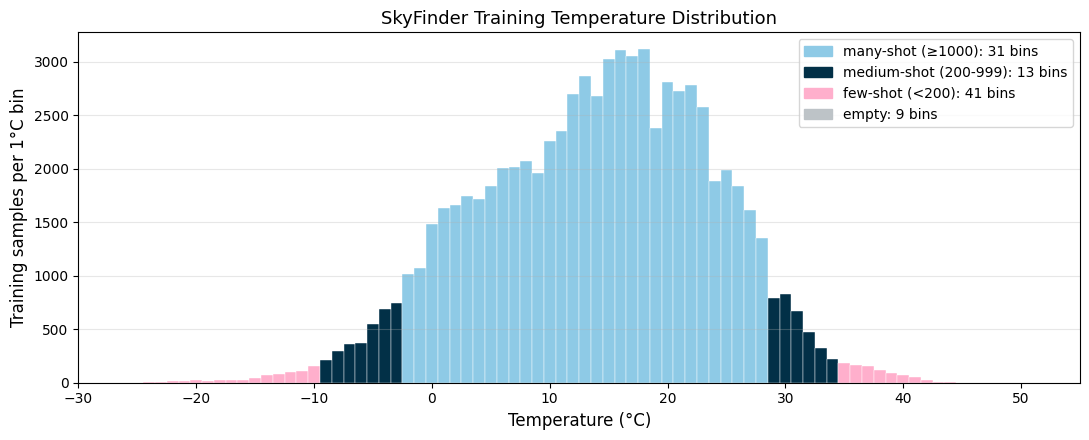

✓ Saved: /content/fig_teaser_distribution.png


In [ ]:
# === Fig 1 — Teaser (Temperature Distribution + Shot Buckets) ===
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
from matplotlib.patches import Patch

df = pd.read_csv(str(SPLIT_CSV))
train = df[df["split"] == "train"]

bins = np.arange(-30, 56, 1)
counts, _ = np.histogram(train["temperature_c"], bins=bins)

shot_per_bin = []
for b_left in bins[:-1]:
    mask = (train["temperature_c"] >= b_left) & (train["temperature_c"] < b_left + 1)
    shots = train.loc[mask, "shot_1000_200"].values
    shot_per_bin.append(Counter(shots).most_common(1)[0][0] if len(shots) > 0 else "none")

colors = {
    "many": "#8ecae6",
    "medium": "#023047",
    "few": "#ffafcc",
    "none": "#bdc3c7"
}

bar_colors = [colors[s] for s in shot_per_bin]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(
    bins[:-1],
    counts,
    color=bar_colors,
    width=1.0,
    edgecolor="white",
    linewidth=0.3
)

ax.set_xlabel("Temperature (°C)", fontsize=12)
ax.set_ylabel("Training samples per 1°C bin", fontsize=12)
ax.set_title("SkyFinder Training Temperature Distribution", fontsize=13)
ax.set_xlim(-30, 55)

handles = [
    Patch(color="#8ecae6", label="many-shot (≥1000): 31 bins"),
    Patch(color="#023047", label="medium-shot (200-999): 13 bins"),
    Patch(color="#ffafcc", label="few-shot (<200): 41 bins"),
    Patch(color="#bdc3c7", label="empty: 9 bins")
]

ax.legend(handles=handles, loc="upper right", fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/content/fig_teaser_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Saved: /content/fig_teaser_distribution.png")

This figure shows that the temperature label distribution in the SkyFinder training set is highly imbalanced. Most samples are concentrated in the moderate temperature range of approximately **0°C–25°C**, with the highest density around **15°C–20°C**, where each 1°C bin contains more than **3,000** training samples. In contrast, the low- and high-temperature tails are much sparser. For example, temperatures below **-20°C** and above **35°C** mostly fall into **few-shot** or **empty** bins. According to the legend, the training set contains only **31 many-shot bins**, but these bins cover the majority of samples. Meanwhile, there are **41 few-shot bins** and **9 empty bins**, indicating that although the label space spans a wide temperature range, the training density is heavily biased toward the middle-temperature region.


### Fig 2 - LDS Weight Visualization

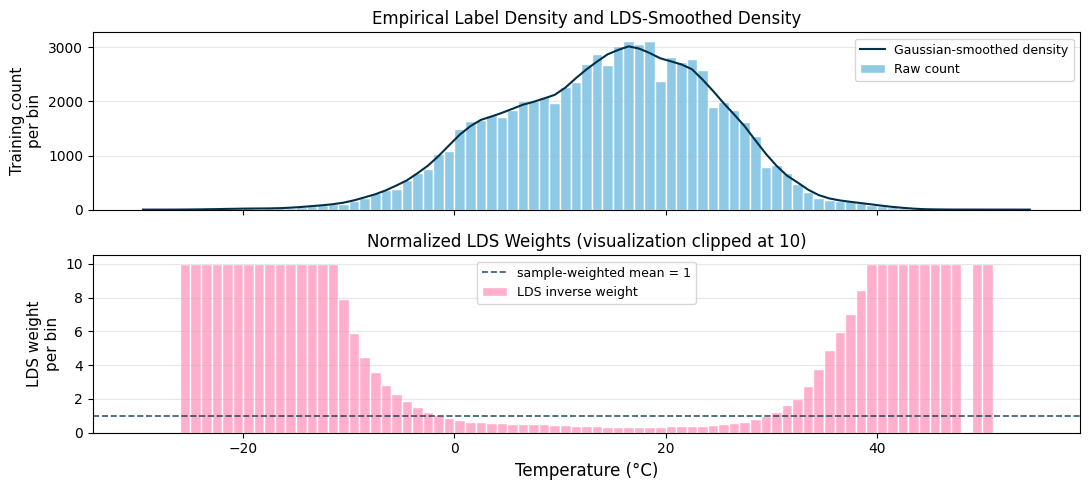

Saved: /content/drive/MyDrive/Colab Notebooks/SkyFinder/figures/figB_lds_weights.png


In [25]:
# === Fig 2 - LDS Weight Visualization ===
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

counts = get_train_bin_counts(str(SPLIT_CSV)).astype(float)
temps = np.arange(TEMP_MIN, TEMP_MAX) + 0.5

def gaussian_kernel1d(ks=5, sigma=2.0):
    """Create a normalized 1D Gaussian kernel."""
    radius = ks // 2
    x = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (x / sigma) ** 2)
    kernel = kernel / kernel.sum()
    return kernel

def compute_lds_weights_for_plot(counts, ks=5, sigma=2.0, eps=1e-6, clip_max=10.0):
    """
    Compute LDS inverse-density weights for visualization.

    Empty bins are set to NaN because they do not contribute samples during training.
    Weights are normalized so the sample-weighted average weight is approximately 1.
    """
    kernel = gaussian_kernel1d(ks=ks, sigma=sigma)

    # Smooth empirical label density
    smoothed_counts = np.convolve(counts, kernel, mode="same")

    # Only bins with training samples should have training weights
    valid = counts > 0

    weights = np.full_like(counts, np.nan, dtype=float)

    # Inverse smoothed density
    weights[valid] = 1.0 / np.maximum(smoothed_counts[valid], eps)

    # Normalize by sample-weighted mean so the average training weight is around 1
    sample_weighted_mean = np.nansum(counts[valid] * weights[valid]) / np.sum(counts[valid])
    weights[valid] = weights[valid] / sample_weighted_mean

    # Clip only for stable visualization
    weights_plot = weights.copy()
    weights_plot[valid] = np.clip(weights_plot[valid], 0, clip_max)

    return smoothed_counts, weights, weights_plot

smoothed_counts, lds_w_raw, lds_w_plot = compute_lds_weights_for_plot(
    counts,
    ks=5,
    sigma=2.0,
    clip_max=10.0
)

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)

# Top panel: raw empirical label density
axes[0].bar(
    temps,
    counts,
    color="#8ecae6",
    edgecolor="white",
    width=1.0,
    label="Raw count"
)

# Overlay Gaussian-smoothed LDS density
axes[0].plot(
    temps,
    smoothed_counts,
    color="#023047",
    linewidth=1.5,
    label="Gaussian-smoothed density"
)

axes[0].set_ylabel("Training count\nper bin", fontsize=11)
axes[0].set_title("Empirical Label Density and LDS-Smoothed Density", fontsize=12)
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend(fontsize=9)

# Bottom panel: LDS inverse-density weights
axes[1].bar(
    temps,
    lds_w_plot,
    color="#ffafcc",
    edgecolor="white",
    width=1.0,
    label="LDS inverse weight"
)

axes[1].axhline(
    1.0,
    color="#023047",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
    label="sample-weighted mean = 1"
)

axes[1].set_ylabel("LDS weight\nper bin", fontsize=11)
axes[1].set_xlabel("Temperature (°C)", fontsize=12)
axes[1].set_title(
    "Normalized LDS Weights (visualization clipped at 10)",
    fontsize=12
)
axes[1].set_ylim(0, 10.5)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend(fontsize=9)

plt.tight_layout()

out_path = "/content/drive/MyDrive/Colab Notebooks/SkyFinder/figures/figB_lds_weights.png"
Path(out_path).parent.mkdir(parents=True, exist_ok=True)

plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {out_path}")

> Figure 2 shows that the SkyFinder training labels are highly concentrated in the middle temperature range, while the low- and high-temperature tails are sparse. After Gaussian smoothing, the label density keeps the same overall shape but becomes less noisy. The inverse LDS weights are therefore lowest in dense regions and highest in sparse tail regions.


### Fig 3 - Per-bin RMSE comparison

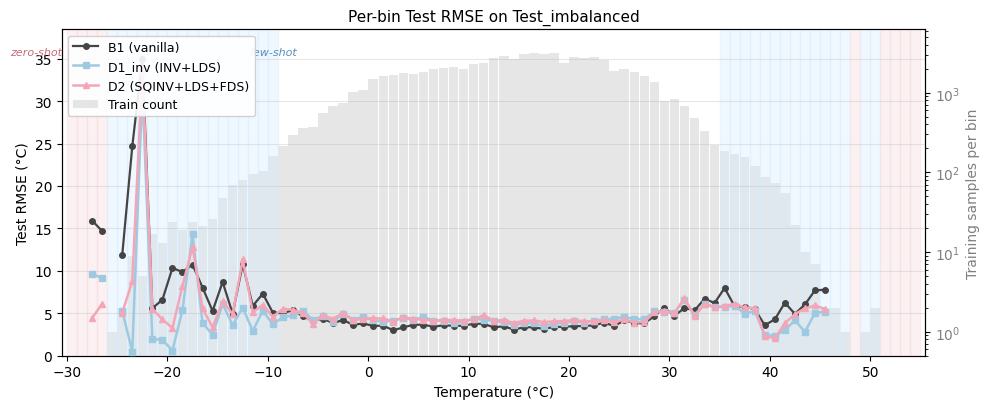

Saved: /content/drive/MyDrive/Colab Notebooks/SkyFinder/figures/fig3_per_bin_rmse.pdf


In [22]:
# === Fig 3: Per-bin RMSE comparison (B1 vs D1_inv vs D2) ===
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Use the all_preds dictionary generated in Cell 39
def per_bin_rmse(errs, bins, n_bins=N_BINS):
    """Compute RMSE for each temperature bin."""
    rmse = np.full(n_bins, np.nan)
    for b in range(n_bins):
        m = bins == b
        if m.any():
            rmse[b] = np.sqrt((errs[m] ** 2).mean())
    return rmse

train_counts = get_train_bin_counts(b1_cfg["csv"])
shot_of_bin_arr = get_shot_of_bin(b1_cfg["csv"], "shot_1000_200")
temps = TEMP_MIN + np.arange(N_BINS) + 0.5  # bin centers

# Extract per-bin RMSE on the imbalanced test set
preds_b1 = all_preds["B1"]["test_imb"]
preds_d1i = all_preds["D1_inv"]["test_imb"]
preds_d2 = all_preds["D2"]["test_imb"]

rmse_b1 = per_bin_rmse(preds_b1["errs"], preds_b1["bins"])
rmse_d1i = per_bin_rmse(preds_d1i["errs"], preds_d1i["bins"])
rmse_d2 = per_bin_rmse(preds_d2["errs"], preds_d2["bins"])

fig, ax1 = plt.subplots(figsize=(10, 4.2))

# Background: training sample count per temperature bin
ax2 = ax1.twinx()
ax2.bar(
    temps,
    train_counts,
    width=0.95,
    color="lightgray",
    alpha=0.55,
    edgecolor="none",
    label="Train count",
    zorder=1,
)
ax2.set_ylabel("Training samples per bin", color="gray")
ax2.tick_params(axis="y", labelcolor="gray")
ax2.set_yscale("log")
ax2.set_ylim(0.5, train_counts.max() * 2)

# Foreground: per-bin test RMSE
ax1.plot(
    temps,
    rmse_b1,
    "o-",
    color="#444444",
    lw=1.6,
    ms=4,
    label="B1 (vanilla)",
    zorder=3,
)
ax1.plot(
    temps,
    rmse_d1i,
    "s-",
    color="#9ecae1",   # light blue
    lw=1.8,
    ms=4,
    label="D1_inv (INV+LDS)",
    zorder=3,
)
ax1.plot(
    temps,
    rmse_d2,
    "^-",
    color="#f4a6b7",   # light pink
    lw=1.8,
    ms=4,
    label="D2 (SQINV+LDS+FDS)",
    zorder=3,
)

# Highlight zero-shot and few-shot temperature regions
for b in range(N_BINS):
    color = {
        -1: "#f8d7da",  # light pink for zero-shot bins
         0: "#d6ecff",  # light blue for few-shot bins
         1: None,
         2: None,
    }[shot_of_bin_arr[b]]

    if color:
        ax1.axvspan(
            temps[b] - 0.5,
            temps[b] + 0.5,
            color=color,
            alpha=0.35,
            zorder=0,
        )

ax1.set_xlabel("Temperature (°C)")
ax1.set_ylabel("Test RMSE (°C)")
ax1.set_xlim(temps.min() - 1, temps.max() + 1)
ax1.set_ylim(
    0,
    max(
        np.nanmax(rmse_b1),
        np.nanmax(rmse_d1i),
        np.nanmax(rmse_d2),
    ) * 1.1,
)
ax1.grid(axis="y", alpha=0.3, zorder=0)
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

# Merge legends from both axes
lines, labels = ax1.get_legend_handles_labels()
bars, blabels = ax2.get_legend_handles_labels()
ax1.legend(
    lines + bars,
    labels + blabels,
    loc="upper left",
    framealpha=0.9,
    fontsize=9,
)

# Annotate zero-shot and few-shot regions
zero_bins = np.where(shot_of_bin_arr == -1)[0]
few_bins = np.where(shot_of_bin_arr == 0)[0]

if len(zero_bins) > 0:
    ax1.text(
        temps[zero_bins[0]] - 1,
        ax1.get_ylim()[1] * 0.92,
        "zero-shot",
        fontsize=8,
        color="#c76c7a",
        ha="right",
        style="italic",
    )

if len(few_bins) > 0:
    ax1.text(
        temps[few_bins[len(few_bins) // 2]],
        ax1.get_ylim()[1] * 0.92,
        "few-shot",
        fontsize=8,
        color="#5b8db8",
        ha="center",
        style="italic",
    )

plt.title("Per-bin Test RMSE on Test_imbalanced", fontsize=11)
plt.tight_layout()

out_path = "/content/drive/MyDrive/Colab Notebooks/SkyFinder/figures/fig3_per_bin_rmse.pdf"
Path(out_path).parent.mkdir(parents=True, exist_ok=True)

plt.savefig(out_path, bbox_inches="tight", dpi=200)
plt.savefig(out_path.replace(".pdf", ".png"), bbox_inches="tight", dpi=150)

plt.show()
print(f"Saved: {out_path}")

Figure 3 shows that the SkyFinder temperature distribution is highly imbalanced, with most training samples concentrated in moderate temperature ranges and very sparse coverage in extreme low- and high-temperature bins. The vanilla baseline exhibits large RMSE spikes in low-shot regions, especially in extreme cold bins. In comparison, LDS-based reweighting and the full DIR model reduce errors in several tail bins, suggesting that distribution-aware training can improve robustness under label imbalance. However, the improvements are not uniform across all rare bins, indicating that extreme zero-shot or near-zero-shot regions remain challenging.

D1/D2 improve robustness in low-density temperature regions, but FDS does not uniformly dominate LDS-only reweighting in every bin.

### Fig 4 - D2 vs D2_inv validation curves

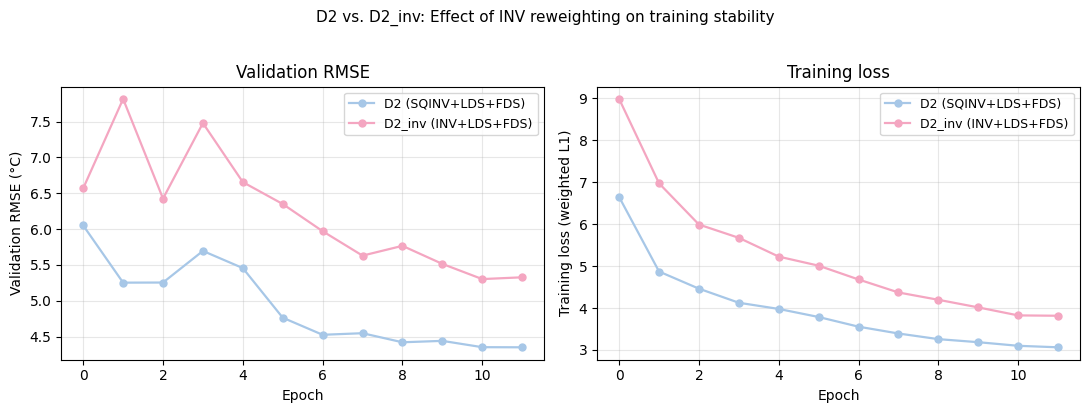

Saved: /content/drive/MyDrive/Colab Notebooks/SkyFinder/figures/fig_d2inv_curve.pdf


In [27]:
# === Fig 4: D2 vs D2_inv validation curves ===
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

DRIVE_RUNS = Path(b1_cfg["drive_runs_root"])

def load_history(name):
    p = DRIVE_RUNS / name / "history.csv"
    return pd.read_csv(p) if p.exists() else None

curves = {
    "D2 (SQINV+LDS+FDS)": load_history("D2"),
    "D2_inv (INV+LDS+FDS)": load_history("D2_inv"),
}

# custom colors
light_blue = "#A7C7E7"
pink = "#F4A6C1"

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: validation RMSE
for name, df in curves.items():
    if df is None:
        continue
    color = light_blue if "_inv" not in name else pink
    axes[0].plot(df["epoch"], df["RMSE"], "o-", lw=1.6, ms=5,
                 color=color, label=name)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation RMSE (°C)")
axes[0].set_title("Validation RMSE")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=9)

# Right: train loss
for name, df in curves.items():
    if df is None:
        continue
    color = light_blue if "_inv" not in name else pink
    axes[1].plot(df["epoch"], df["train_loss"], "o-", lw=1.6, ms=5,
                 color=color, label=name)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Training loss (weighted L1)")
axes[1].set_title("Training loss")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=9)

plt.suptitle("D2 vs. D2_inv: Effect of INV reweighting on training stability",
             fontsize=11, y=1.02)
plt.tight_layout()
out_path = "/content/drive/MyDrive/Colab Notebooks/SkyFinder/figures/fig_d2inv_curve.pdf"
plt.savefig(out_path, bbox_inches="tight", dpi=200)
plt.savefig(out_path.replace(".pdf", ".png"), bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved: {out_path}")

Figure 4 compares the validation RMSE and training loss of D2 and D2_inv. Across all epochs, D2 consistently achieves lower validation RMSE than D2_inv, indicating better generalization under sqrt-inverse reweighting. D2_inv starts with substantially higher RMSE and training loss, suggesting that full inverse reweighting assigns overly large weights to rare temperature bins and makes optimization less stable. Although D2_inv gradually improves, it remains worse than D2 throughout training. In contrast, D2 shows a smoother loss curve and reaches a lower final validation RMSE, supporting the use of SQINV+LDS+FDS as the more stable and effective configuration.

### Fig 5 - Zero-shot RMSE comparison

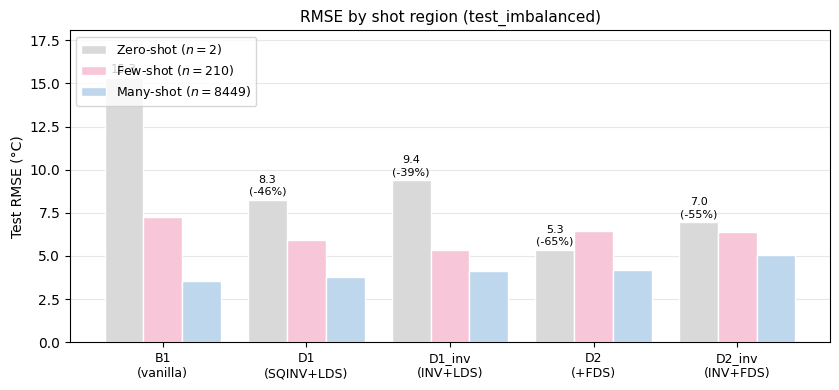

Saved: /content/drive/MyDrive/Colab Notebooks/SkyFinder/figures/fig_zero_shot_advantage.pdf


In [29]:
# === Fig 5 - Zero-shot RMSE comparison ===
import matplotlib.pyplot as plt
import numpy as np

shot_of_bin_arr = get_shot_of_bin(b1_cfg["csv"], "shot_1000_200")

methods = ["B1", "D1", "D1_inv", "D2", "D2_inv"]
labels = ["B1\n(vanilla)", "D1\n(SQINV+LDS)", "D1_inv\n(INV+LDS)",
          "D2\n(+FDS)", "D2_inv\n(INV+FDS)"]

zero_rmse, few_rmse, many_rmse = [], [], []
for m in methods:
    if m not in all_preds:
        continue
    p = all_preds[m]["test_imb"]
    shots = shot_of_bin_arr[p["bins"]]
    zero_rmse.append(np.sqrt((p["errs"][shots == -1]**2).mean()))
    few_rmse.append(np.sqrt((p["errs"][shots == 0]**2).mean()))
    many_rmse.append(np.sqrt((p["errs"][shots == 2]**2).mean()))

x = np.arange(len(methods))
width = 0.27

# colors: light gray / light pink / light blue
light_gray = "#D9D9D9"
light_pink = "#F7C6D9"
light_blue = "#BFD7ED"

fig, ax = plt.subplots(figsize=(8.5, 4))
b1 = ax.bar(x - width, zero_rmse, width, label="Zero-shot ($n=2$)",
            color=light_gray, edgecolor="white")
b2 = ax.bar(x,         few_rmse,  width, label="Few-shot ($n=210$)",
            color=light_pink, edgecolor="white")
b3 = ax.bar(x + width, many_rmse, width, label="Many-shot ($n=8449$)",
            color=light_blue, edgecolor="white")

b1_zero_baseline = zero_rmse[0]
for i, val in enumerate(zero_rmse):
    if i == 0:
        ax.text(x[i] - width, val + 0.3, f"{val:.1f}", ha="center", fontsize=8.5)
    else:
        delta = (val - b1_zero_baseline) / b1_zero_baseline * 100
        ax.text(x[i] - width, val + 0.3,
                f"{val:.1f}\n({delta:+.0f}%)", ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Test RMSE (°C)")
ax.set_title("RMSE by shot region (test_imbalanced)", fontsize=11)
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.set_ylim(0, max(zero_rmse) * 1.18)

plt.tight_layout()
out_path = "/content/drive/MyDrive/Colab Notebooks/SkyFinder/figures/fig_zero_shot_advantage.pdf"
plt.savefig(out_path, bbox_inches="tight", dpi=200)
plt.savefig(out_path.replace(".pdf", ".png"), bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved: {out_path}")

## Key Findings

| Finding                              | Evidence                                                                                                                          | Interpretation                                                                                                |
|--------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------------|
| LDS inverse transfers to SkyFinder   | D1_inv reduces balanced few-shot RMSE from 6.21 to 5.61 (-9.7%) and few-shot GM from 4.05 to 2.13 (-47%). D1 (sqrt_inv) reduces few-shot GM (-27%) but not RMSE. | LDS helps sparse temperature bins, with the more aggressive inverse variant giving the cleanest few-shot improvement. |
| Inverse reweighting has a many-shot trade-off | D1_inv increases balanced many-shot RMSE from 3.62 to 4.93 (+36%).                                                       | Strong tail correction improves few-shot at the cost of frequent regions — the canonical DIR trade-off.       |
| FDS helps zero-shot but not few-shot | D2 worsens few-shot RMSE (6.37 -> 6.79) but achieves best zero-shot RMSE (5.35 vs B1 15.32).                                      | FDS's kernel-based statistics borrowing helps the most extreme tail rather than moderately rare bins.         |
| Results are threshold-robust         | The same pattern appears under 100/20, 500/50, and 1000/200 thresholds.                                                           | The conclusion is not driven by a single shot-region definition.                                              |

Overall, the results are directionally consistent with the DIR paper: kernel smoothing improves underrepresented continuous targets, with the canonical few/many trade-off. For SkyFinder, D1_inv is the strongest configuration for few-shot performance, while FDS provides marginal zero-shot benefit but no additional few-shot gain over LDS alone.